In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv("/content/housing.csv", sep=r"\s+", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       506 non-null    float64
 1   1       506 non-null    float64
 2   2       506 non-null    float64
 3   3       506 non-null    int64  
 4   4       506 non-null    float64
 5   5       506 non-null    float64
 6   6       506 non-null    float64
 7   7       506 non-null    float64
 8   8       506 non-null    int64  
 9   9       506 non-null    float64
 10  10      506 non-null    float64
 11  11      506 non-null    float64
 12  12      506 non-null    float64
 13  13      506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
y = data.iloc[:,[13]].to_numpy()
x = data.iloc[:,0:13].to_numpy()

scaler = StandardScaler()
x = scaler.fit_transform(x)

x = x.astype(np.float32)
y = y.astype(np.float32)

x = torch.from_numpy(x)
y = torch.from_numpy(y)

In [6]:
x_train,x_test, y_train, y_test = train_test_split(x,y, train_size = 0.7, random_state = 42)

In [7]:
train_dataset = TensorDataset(x_train,y_train)
test_dataset = TensorDataset(x_test,y_test)

In [8]:
train_loader = DataLoader(train_dataset, batch_size = 50, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 50, shuffle = False)

In [9]:
model = nn.Sequential(
    # nn.Linear(in_features, out_features)
    nn.Linear(13, 128),   # Input layer: 13 features → 128 neurons
    nn.ReLU(),            # Activation function (introduces non-linearity)
    nn.Dropout(0.2),      # Regularization: randomly turns off 20% of neurons during training
    nn.Linear(128, 128),  # Hidden layer: 128 → 128
    nn.ReLU(),            # Another ReLU
    nn.Linear(128, 64),   # Hidden layer: 128 → 64
    nn.ReLU(),            # ReLU again
    nn.Linear(64, 1)      # Output layer: 64 → 1 (single value: predicted price)
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

**nn.Dropout(0.2)** – during training, randomly sets 20% of the neurons in the previous layer to zero. This prevents overfitting by making the network more robust.

In [10]:
model

Sequential(
  (0): Linear(in_features=13, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=64, bias=True)
  (6): ReLU()
  (7): Linear(in_features=64, out_features=1, bias=True)
)

Epoch 50, Avg Loss: 15.9968
Epoch 100, Avg Loss: 9.7308
Epoch 150, Avg Loss: 8.7267
Epoch 200, Avg Loss: 6.8536
Epoch 250, Avg Loss: 6.7266
Epoch 300, Avg Loss: 6.8644
Epoch 350, Avg Loss: 5.6838
Epoch 400, Avg Loss: 4.3299
Epoch 450, Avg Loss: 3.8825
Epoch 500, Avg Loss: 3.3405
Epoch 550, Avg Loss: 4.4372
Epoch 600, Avg Loss: 3.1167
Epoch 650, Avg Loss: 3.2764
Epoch 700, Avg Loss: 3.6900
Epoch 750, Avg Loss: 3.2169
Epoch 800, Avg Loss: 2.6056
Epoch 850, Avg Loss: 2.6591
Epoch 900, Avg Loss: 2.6669
Epoch 950, Avg Loss: 2.5453
Epoch 1000, Avg Loss: 2.4314


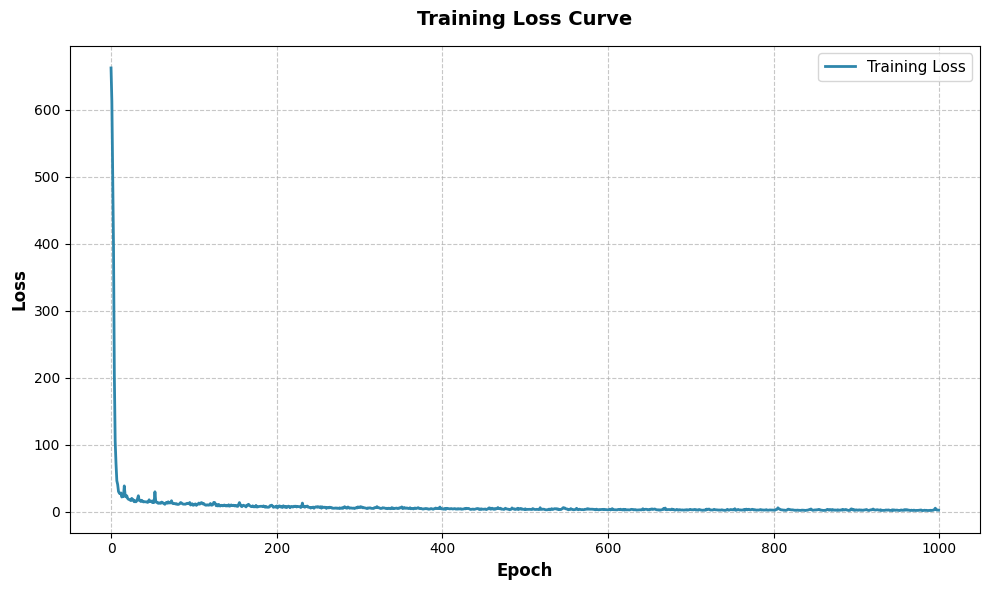


Training completed!
Final loss: 2.431420
Best loss: 1.797868 (Epoch 981)


In [11]:
import matplotlib.pyplot as plt

# Track losses for plotting
train_losses = []

for epoch in range(1000):
    running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)  # Store loss for plotting

    if (epoch + 1) % 50 == 0:  # Print every 50 epochs to reduce clutter
        print(f"Epoch {epoch+1}, Avg Loss: {epoch_loss:.4f}")

# Plot training loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='#2E86AB', linewidth=2)
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss Curve', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=300, bbox_inches='tight')  # Save high-res version
plt.show()

# Optional: Print final statistics
print(f"\nTraining completed!")
print(f"Final loss: {train_losses[-1]:.6f}")
print(f"Best loss: {min(train_losses):.6f} (Epoch {train_losses.index(min(train_losses)) + 1})")

In [14]:
train_losses

[662.6887588500977,
 612.8696365356445,
 504.6156196594238,
 395.57587814331055,
 203.97431087493896,
 105.604416847229,
 72.05649852752686,
 46.39270055294037,
 40.85248303413391,
 30.37255048751831,
 27.808360815048218,
 26.840830087661743,
 28.18172836303711,
 22.022017627954483,
 24.016943097114563,
 22.73046350479126,
 38.67782473564148,
 24.995724201202393,
 22.30940866470337,
 23.91669011116028,
 20.06918454170227,
 18.71386456489563,
 18.293297290802002,
 17.503528714179993,
 16.71807962656021,
 20.028128743171692,
 17.60131013393402,
 17.79570186138153,
 14.950459003448486,
 16.34151464700699,
 14.881088256835938,
 16.1706520318985,
 19.60123336315155,
 23.954656839370728,
 17.03359091281891,
 16.56198787689209,
 15.387427568435669,
 17.220158576965332,
 15.97451663017273,
 14.730534076690674,
 15.212582468986511,
 14.841498613357544,
 14.870053172111511,
 14.928831398487091,
 14.043759644031525,
 14.556433320045471,
 17.957168102264404,
 15.556525230407715,
 15.20873141288757

In [12]:
model.eval()
test_loss = 0.0
y_true = []
y_pred = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model(x_batch)
        loss = criterion(output, y_batch)
        test_loss += loss.item()

        y_true.append(y_batch)
        y_pred.append(output)

y_true = torch.cat(y_true, dim=0)
y_pred = torch.cat(y_pred, dim=0)

avg_test_loss = test_loss / len(test_loader)
print(f"Test Loss (MSE): {avg_test_loss:.4f}")

Test Loss (MSE): 7.9015


In [13]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true.numpy(), y_pred.numpy())
print(f"R² Score: {r2:.4f}")

R² Score: 0.8811
